In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False) 

X, y = mnist.data, mnist.target
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [3]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [8]:
from sklearn.linear_model import SGDClassifier
import importlib
import matplotlib.pyplot as plt
sgd_clf = SGDClassifier(random_state=42)

test cross_val_score

In [5]:
print('------------------ Custom ------------------')
from cross_val import cross_val_score
print(cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy"))


print('------------------ Original ------------------')
from sklearn.model_selection import cross_val_score
print(cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy"))

------------------ Custom ------------------
[0.9688  0.96825 0.96845]
------------------ Original ------------------
[0.95035 0.96035 0.9604 ]


In [6]:
print('------------------ Custom ------------------')
import cross_val
importlib.reload(cross_val)
from cross_val import cross_val_predict
y_train_pred_cus = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
print(y_train_pred_cus)


print('------------------ Original ------------------')
from sklearn.model_selection import cross_val_predict
y_train_pred_org = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
print(y_train_pred_org)

------------------ Custom ------------------
[ True False False ...  True False False]
------------------ Original ------------------
[ True False False ...  True False False]


In [7]:
import numpy as np
print(np.all(y_train_pred_cus == y_train_pred_org))
print('Org true', y_train_pred_org.sum())
print('Cus true', y_train_pred_cus.sum())

False
Org true 4217
Cus true 5679


In [8]:
import class_score_funcs
importlib.reload(class_score_funcs)

from class_score_funcs import confusion_matrix
print(confusion_matrix(y_train_5, y_train_pred_org))

print(confusion_matrix(y_train_5, y_train_5))

[[53892   687]
 [ 1891  3530]]
[[54579     0]
 [    0  5421]]


In [9]:
import class_score_funcs
importlib.reload(class_score_funcs)

from class_score_funcs import precision_score, recall_score, f1_score
print(precision_score(y_train_5, y_train_pred_org))
print(recall_score(y_train_5, y_train_pred_org))
print(f1_score(y_train_5, y_train_pred_org))

0.8370879772350012
0.6511713705958311
0.7325171197343847


In [10]:
importlib.reload(class_score_funcs)
from class_score_funcs import confusion_matrix

y_true = [2, 0, 2, 2, 0, 1]
y_pred = [0, 0, 2, 2, 0, 2]
confusion_matrix(y_true, y_pred)

# array([[2, 0, 0],
#        [0, 0, 1],
#        [1, 0, 2]])

array([[2, 0, 0],
       [0, 0, 1],
       [1, 0, 2]])

In [11]:
y_true = ["cat", "ant", "cat", "cat", "ant", "bird"]
y_pred = ["ant", "ant", "cat", "cat", "ant", "cat"]
confusion_matrix(y_true, y_pred)

# array([[2, 0, 0],
#        [0, 0, 1],
#        [1, 0, 2]])

array([[2, 0, 0],
       [0, 0, 1],
       [1, 0, 2]])

In [58]:
import cross_val
importlib.reload(cross_val)
from cross_val import cross_val_predict
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")
print(y_scores)


from sklearn.model_selection import cross_val_predict
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")
print(y_scores)

[  9592.95445506 -15395.8493179  -29305.26164733 ...   6809.1165058
  -9235.61971047 -18206.02453806]
[  1200.93051237 -26883.79202424 -33072.03475406 ...  13272.12718981
  -7258.47203373 -16877.50840447]


In [13]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)

import cross_val
importlib.reload(cross_val)
from cross_val import cross_val_predict
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")
print(y_probas_forest)

from sklearn.model_selection import cross_val_predict
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")
print(y_probas_forest)

[[0.08 0.92]
 [1.0 0.0]
 [0.97 0.03]
 ...
 [0.02 0.98]
 [0.96 0.04]
 [0.92 0.08]]
[[0.11 0.89]
 [0.99 0.01]
 [0.96 0.04]
 ...
 [0.02 0.98]
 [0.92 0.08]
 [0.94 0.06]]


In [14]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
print(precisions)
print(recalls)
print(thresholds)

print(len(precisions))
print(len(thresholds))
print(len(y_scores))

print('--------------- Custom ---------------')
import class_score_funcs
importlib.reload(class_score_funcs)
from class_score_funcs import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
print(precisions)
print(recalls)
print(thresholds)

print(len(precisions))
print(len(thresholds))

[0.09035    0.09035151 0.09035301 ... 1.         1.         1.        ]
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 3.68935621e-04
 1.84467810e-04 0.00000000e+00]
[-146348.56726174 -142300.00705404 -137588.97581744 ...   38871.26391927
   42216.05562787   49441.43765905]
60001
60000
60000
--------------- Custom ---------------
[0.09035    0.09035151 0.09035301 ... 1.         1.         0.09035   ]
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 3.68935621e-04
 1.84467810e-04 1.00000000e+00]
[-146348.56726174 -142300.00705404 -137588.97581744 ...   38871.26391927
   42216.05562787   49441.43765905]
60001
60000


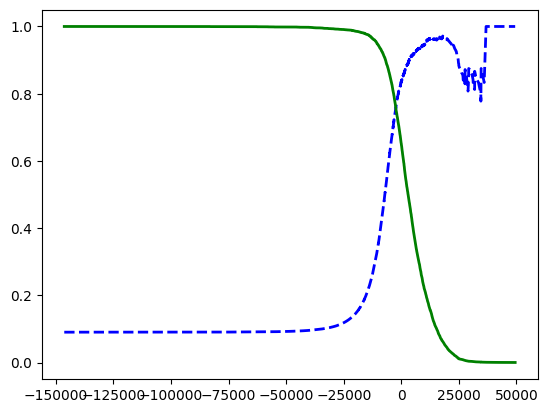

In [15]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
# plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
# [...] # beautify the figure: add grid, legend, axis, labels, and circles
plt.show()

In [64]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

print(fpr)
print(tpr)
print(thresholds)

print(len(fpr))
print(len(tpr))
print(len(thresholds))

print('--------------- Custom ---------------')
import class_score_funcs
importlib.reload(class_score_funcs)
from class_score_funcs import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

print(fpr)
print(tpr)
print(thresholds)

print(len(fpr))
print(len(tpr))
print(len(thresholds))

[0.         0.         0.         ... 0.99937705 0.99937705 1.        ]
[0.00000000e+00 1.84467810e-04 9.22339052e-04 ... 9.99815532e-01
 1.00000000e+00 1.00000000e+00]
[             inf   49441.43765905   36801.60697028 ... -105763.22240074
 -106527.45300471 -146348.56726174]
3908
3908
3908
--------------- Custom ---------------
[0.         0.         0.         ... 0.99996336 0.99998168 1.        ]
[0.00000000e+00 1.84467810e-04 3.68935621e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
[             inf   49441.43765905   42216.05562787 ... -137588.97581744
 -142300.00705404 -146348.56726174]
60001
60001
60001


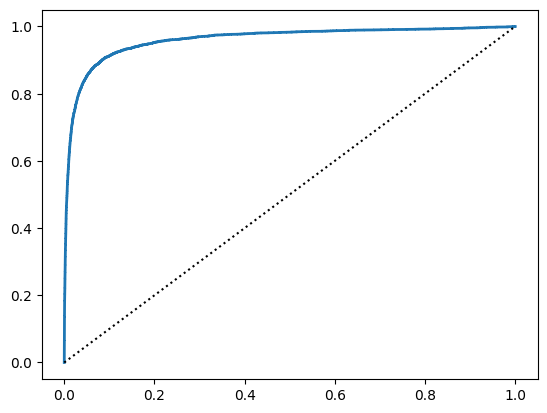

In [65]:
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.show()

In [66]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_train_5, y_scores))

print('--------------- Custom ---------------')
import class_score_funcs
importlib.reload(class_score_funcs)
from class_score_funcs import roc_auc_score
print(roc_auc_score(y_train_5, y_scores))


0.9604938554008616
--------------- Custom ---------------
0.9604938554008617


In [ ]:
import class_score_funcs
importlib.reload(class_score_funcs)
from class_score_funcs import get_score

print(get_score(sgd_clf, X_train, y_train_5, precision=0.9, type='recall'))
print(get_score(sgd_clf, X_train, y_train_5, precision=0.9, type='threshold'))

print(get_score(sgd_clf, X_train, y_train_5, recall=0.50, type='precision'))

0.49345139273196825
5132.645925850901
0.8949801849405549


Test confusion_matrix_from_predictions

In [6]:
X_train, y_train = X_train[:20000], y_train[:20000]

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[[1896    0   11    4    3   19   13    2   46    0]
 [   0 2175   19   12    2   17    1    1   48    6]
 [  13   13 1690   39   24   16   24   16   90    4]
 [  12    9   55 1783    1   65   15   22   85   29]
 [   5    4   19    6 1756    3   13    6   62   71]
 [  13   12   14   67   24 1472   25    6  116   26]
 [  16    7   15    2   26   24 1838    4   38    1]
 [   6    3   29   12   17    2    1 1903   21   99]
 [  10   26   24   45    2   45   16    5 1720   29]
 [  16    8   10   31   45   16    1   61   64 1762]]


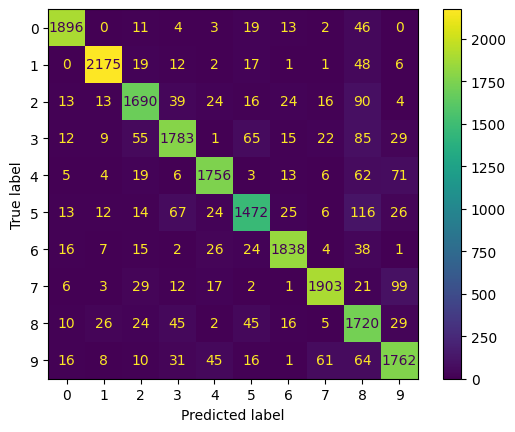

In [10]:
import class_score_funcs
importlib.reload(class_score_funcs)
from class_score_funcs import confusion_matrix_from_predictions

print(confusion_matrix_from_predictions(y_train, y_train_pred))

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()


[[0.95 0.   0.01 0.   0.   0.01 0.01 0.   0.02 0.  ]
 [0.   0.95 0.01 0.01 0.   0.01 0.   0.   0.02 0.  ]
 [0.01 0.01 0.88 0.02 0.01 0.01 0.01 0.01 0.05 0.  ]
 [0.01 0.   0.03 0.86 0.   0.03 0.01 0.01 0.04 0.01]
 [0.   0.   0.01 0.   0.9  0.   0.01 0.   0.03 0.04]
 [0.01 0.01 0.01 0.04 0.01 0.83 0.01 0.   0.07 0.01]
 [0.01 0.   0.01 0.   0.01 0.01 0.93 0.   0.02 0.  ]
 [0.   0.   0.01 0.01 0.01 0.   0.   0.91 0.01 0.05]
 [0.01 0.01 0.01 0.02 0.   0.02 0.01 0.   0.89 0.02]
 [0.01 0.   0.   0.02 0.02 0.01 0.   0.03 0.03 0.87]]


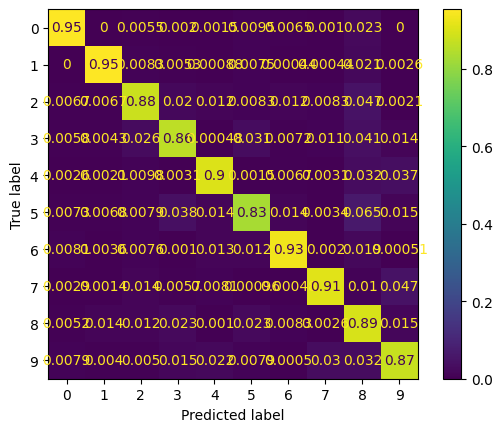

In [13]:
import class_score_funcs
importlib.reload(class_score_funcs)
from class_score_funcs import confusion_matrix_from_predictions

print(confusion_matrix_from_predictions(y_train, y_train_pred, normalize='true'))

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize='true')
plt.show()

[['95%' '0%' '1%' '0%' '0%' '1%' '1%' '0%' '2%' '0%']
 ['0%' '96%' '1%' '1%' '0%' '1%' '0%' '0%' '2%' '0%']
 ['1%' '1%' '90%' '2%' '1%' '1%' '1%' '1%' '4%' '0%']
 ['1%' '0%' '3%' '89%' '0%' '4%' '1%' '1%' '4%' '1%']
 ['0%' '0%' '1%' '0%' '92%' '0%' '1%' '0%' '3%' '4%']
 ['1%' '1%' '1%' '3%' '1%' '88%' '1%' '0%' '5%' '1%']
 ['1%' '0%' '1%' '0%' '1%' '1%' '94%' '0%' '2%' '0%']
 ['0%' '0%' '2%' '1%' '1%' '0%' '0%' '94%' '1%' '5%']
 ['1%' '1%' '1%' '2%' '0%' '3%' '1%' '0%' '75%' '1%']
 ['1%' '0%' '1%' '2%' '2%' '1%' '0%' '3%' '3%' '87%']]


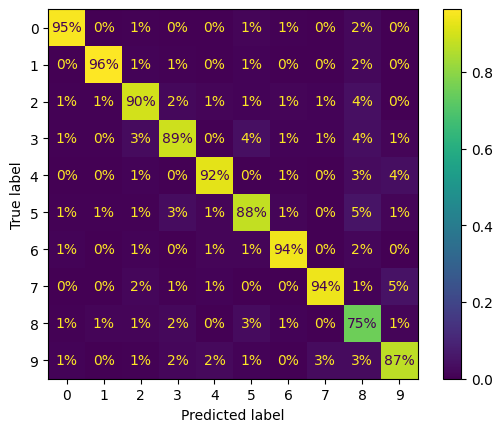

In [18]:
import class_score_funcs
importlib.reload(class_score_funcs)
from class_score_funcs import confusion_matrix_from_predictions

print(confusion_matrix_from_predictions(y_train, y_train_pred, normalize='pred', values_format=".0%"))

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize='pred', values_format=".0%")
plt.show()

[[  0   0  11   4   3  19  13   2  46   0]
 [  0   0  19  12   2  17   1   1  48   6]
 [ 13  13   0  39  24  16  24  16  90   4]
 [ 12   9  55   0   1  65  15  22  85  29]
 [  5   4  19   6   0   3  13   6  62  71]
 [ 13  12  14  67  24   0  25   6 116  26]
 [ 16   7  15   2  26  24   0   4  38   1]
 [  6   3  29  12  17   2   1   0  21  99]
 [ 10  26  24  45   2  45  16   5   0  29]
 [ 16   8  10  31  45  16   1  61  64   0]]


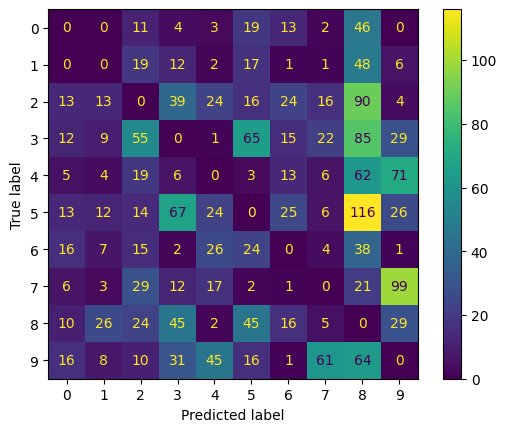

In [16]:
sample_weight = (y_train_pred != y_train)

import class_score_funcs
importlib.reload(class_score_funcs)
from class_score_funcs import confusion_matrix_from_predictions

print(confusion_matrix_from_predictions(y_train, y_train_pred, sample_weight=sample_weight))

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight)
plt.show()